# День 08. Упражнение 02
# Мульти-классовая классификация. One-hot кодирование. Случайный лес

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

## 1. Предобработка


1. Прочитай файл [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Создай DataFrame `df` с колонками: `uid`, `labname`, `numTrials`, `hour`, `dayofweek`, где `hour` извлекается из `timestamp`, а также `dayofweek` (`0` — понедельник, `6` — воскресенье). Мы будем пытаться предсказать день недели, имея данные о том, какой пользователь сделал коммит, для какой лабораторной, в какой час и с какой попытки.
3. С помощью `OneHotEncoder()` преобразуй категориальные признаки, затем удали из DataFrame исходные столбцы.
4. Используй `StandardScaler()` и нормализуй числовые признаки.
5. Сохрани DataFrame как `dayofweek.csv`.
6. Перед тем как пробовать разные алгоритмы, вычисли точность наивного алгоритма — того, который предсказывает всё как самый частый класс.


In [2]:
df = pd.read_csv('../data/checker_submits.csv')

In [3]:
ts = pd.to_datetime(df['timestamp'])
df['hour'] = ts.dt.hour
df['dayofweek'] = ts.dt.dayofweek
df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]

In [4]:
X_cat = pd.get_dummies(df[['uid', 'labname']])
feature_names = list(X_cat.columns) + ['numTrials', 'hour']

In [5]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[['numTrials', 'hour']])

In [6]:
X = np.hstack([X_cat.values, X_num_scaled])
y = df['dayofweek'].values

In [7]:
df_out = pd.DataFrame(X, columns=feature_names)
df_out['dayofweek'] = y
df_out.to_csv('../data/dayofweek.csv', index=False)
print(df_out.shape)

(1686, 44)


In [8]:
naive_pred = pd.Series(y).value_counts().idxmax()
naive_acc = accuracy_score(y, [naive_pred] * len(y))
print(naive_acc)

0.23487544483985764


## 2. Алгоритмы


### a. Логистическая регрессия

1. Обучи логистическую регрессию; для базовой модели используй `random_state=21`, `fit_intercept=False`.
2. Вычисли точность (accuracy).
3. Напиши функцию, которая строит график (`barh`), принимая коэффициенты обученной модели, имена признаков и количество `top-n` наиболее важных признаков для отображения.
4. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели.
5. Помни, что это мульти-классовая классификация, и `coef_` возвращает матрицу — чтобы вычислить важность признака, нужно просуммировать все индивидуальные значения важности этого признака для всех целевых классов.

In [9]:
lr = OneVsRestClassifier(LogisticRegression(random_state=21, fit_intercept=False, max_iter=10000))
lr.fit(X, y)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int32](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...ndom_state=21), LogisticRegre...ndom_state=21), LogisticRegre...ndom_state=21), LogisticRegre...ndom_state=21), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False


In [10]:
pred_lr = lr.predict(X)
print(accuracy_score(y, pred_lr))

0.6209964412811388


In [11]:
def plot_top_features(importances, feature_names, top_n=10):
    indices = np.argsort(importances)[::-1][:top_n][::-1]
    names = [feature_names[i] for i in indices]
    vals = [importances[i] for i in indices]
    plt.figure(figsize=(8, 5))
    plt.barh(range(top_n), vals, tick_label=names)
    plt.gca().invert_yaxis()
    plt.xlabel('Feature importance')
    plt.title(f'Top {top_n} most important features')
    plt.tight_layout()
    plt.show()

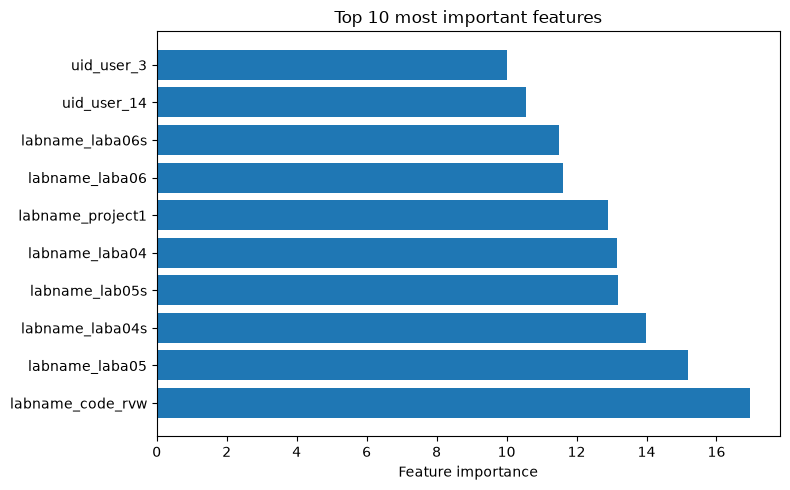

Top-1: labname_code_rvw


In [12]:
imp_lr = np.abs(np.array([est.coef_[0] for est in lr.estimators_])).sum(axis=0)
plot_top_features(imp_lr, feature_names, 10)
print(f'Top-1: {feature_names[np.argmax(imp_lr)]}')

### b. SVC

1. Обучи модель `SVC`; для базовой модели используй параметры `kernel='linear'`, `probability=True`, `random_state=21`.
2. Попробуй разные ядра, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели с линейным ядром.*

*По умолчанию SVC использует стратегию “one vs one” для классификации, поэтому в `coef_` возвращает матрицу. Чтобы вычислить важность признака, нужно использовать [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) поверх SVC и просуммировать все индивидуальные значения важности признака для всех целевых классов.

In [13]:
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc.fit(X, y)

/Users/leyla_iz/Desktop/21/cybernor/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/leyla_iz/Desktop/21/cybernor/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/leyla_iz/Desktop/21/cybernor/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/leyla_iz/Desktop/21/cybernor/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(kernel='l...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int32](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'


In [14]:
pred_svc = svc.predict(X)
print(accuracy_score(y, pred_svc))

0.6126927639383155


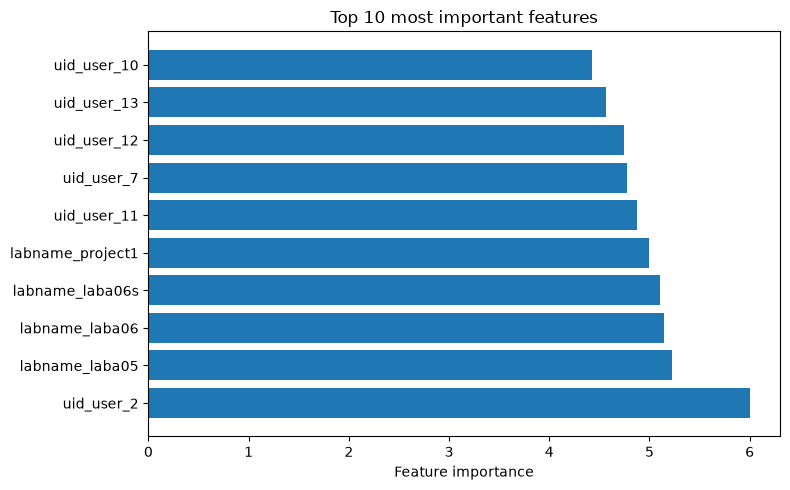

Top-1: uid_user_2


In [15]:
imp_svc = np.abs(np.array([est.coef_[0] for est in svc.estimators_])).sum(axis=0)
plot_top_features(imp_svc, feature_names, 10)
print(f'Top-1: {feature_names[np.argmax(imp_svc)]}')

### c. Дерево решений

1. Обучи `DecisionTreeClassifier`; для базовой модели используй `max_depth=4`, `random_state=21`.
2. Попробуй разные значения `max_depth`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

Accuracy: 0.5516014234875445


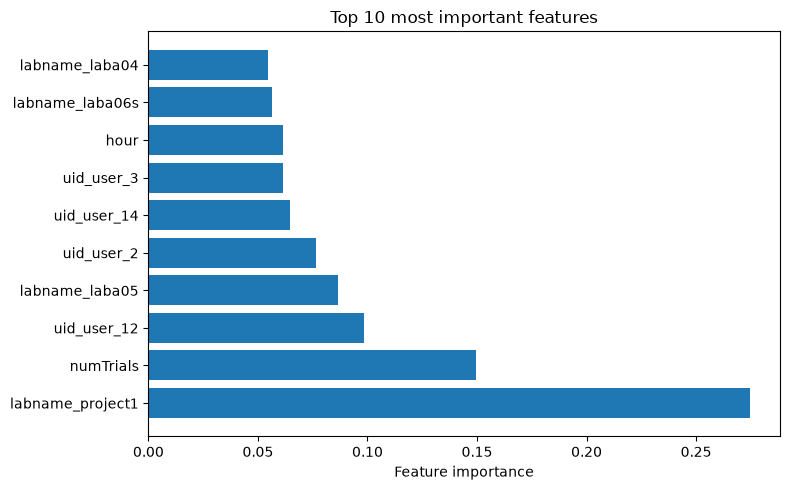

Top-1: labname_project1


In [16]:
dt = DecisionTreeClassifier(max_depth=4, random_state=21)
dt.fit(X, y)
pred_dt = dt.predict(X)
print(f'Accuracy: {accuracy_score(y, pred_dt)}')
plot_top_features(dt.feature_importances_, feature_names, 10)
print(f'Top-1: {feature_names[np.argmax(dt.feature_importances_)]}')

### d. Случайный лес

В реальной жизни лес состоит из множества деревьев. То же самое и в машинном обучении: случайный лес — это набор отдельных деревьев решений (подробнее см. документацию).

1. Обучи `RandomForestClassifier`; для базовой модели используй параметры `n_estimators=100`, `max_depth=25`, `random_state=21`.
2. Попробуй разные значения `max_depth` и `n_estimators`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

Accuracy: 0.9994068801897983


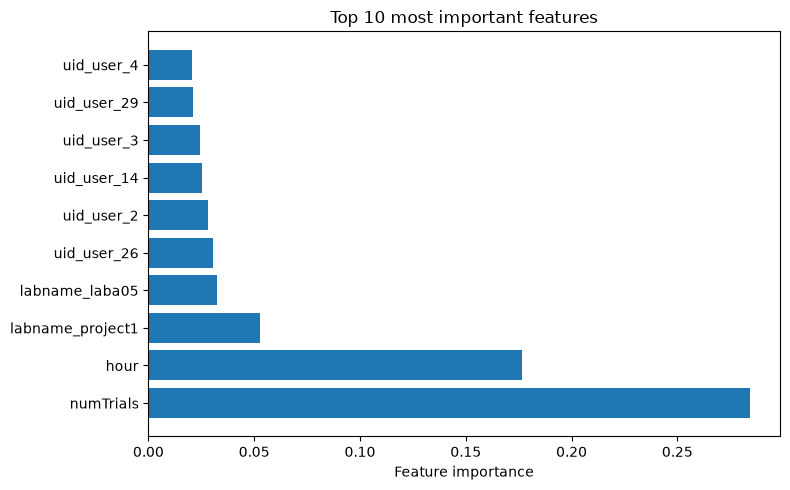

Top-1: numTrials


In [17]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf.fit(X, y)
pred_rf = rf.predict(X)
print(f'Accuracy: {accuracy_score(y, pred_rf)}')
plot_top_features(rf.feature_importances_, feature_names, 10)
print(f'Top-1: {feature_names[np.argmax(rf.feature_importances_)]}')